<a href="https://colab.research.google.com/github/YolandaZhao10/CSCI-6170-Project-in-AI-and-ML/blob/main/hw4/homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 1. Clone nanoGPT and install dependencies
!git clone https://github.com/karpathy/nanoGPT
%cd nanoGPT
!pip install tiktoken

# 2. Prepare the character-level Shakespeare dataset
!python data/shakespeare_char/prepare.py

import torch
import torch.nn as nn
import numpy as np
import os
import pickle
import random

# Record environment for requirements
print(f"GPU: {torch.cuda.get_device_name(0)}")
!pip list | grep -E "torch|numpy|tiktoken"


# seed setup
SEED = 42
def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(SEED)

fatal: destination path 'nanoGPT' already exists and is not an empty directory.
/content/nanoGPT/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
GPU: NVIDIA A100-SXM4-40GB
numpy                                    2.0.2
tiktoken                                 0.12.0
torch                                    2.10.0+cu128
torchao                                  0.10.0
torchaudio                               2.10.0+cu128
torchcodec                               0.10.0+cu128
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cu128


# Task 1: Language Modeling - Part A

In [9]:
import subprocess
import textwrap

runs = {
    "5_epochs": 340,
    "50_epochs": 3400,
    "500_epochs": 34000,
}

base_config = """
eval_interval = 100
eval_iters = 200
log_interval = 10
always_save_checkpoint = True

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.2

learning_rate = 1e-3
lr_decay_iters = {max_iters}
max_iters = {max_iters}
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
device = 'cuda'
compile = False
out_dir = '{out_dir}'
"""

os.makedirs("logs", exist_ok=True)

for label, max_iters in runs.items():
    out_dir = f"out_{label}"
    config_path = f"config/train_{label}.py"
    log_path = f"logs/train_{label}.log"

    config_now = base_config.format(max_iters=max_iters, out_dir=out_dir)
    with open(config_path, "w") as f:
        f.write(config_now)

    print(f"\n===== Training {label} ({max_iters} iterations) =====")

    cmd = [
        "python", "train.py", config_path,
        "--device=cuda",
        "--compile=False"
    ]

    with open(log_path, "w") as logfile:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        for line in process.stdout:
            print(line, end="")
            logfile.write(line)
        process.wait()

print("\nAll three runs finished.")


===== Training 5_epochs (340 iterations) =====
/content/nanoGPT/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_5_epochs.py:

eval_interval = 100
eval_iters = 200
log_interval = 10
always_save_checkpoint = True

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.2

learning_rate = 1e-3
lr_decay_iters = 340
max_iters = 340
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
device = 'cuda'
compile = False
out_dir = 'out_5_epochs'

Overriding: device = cuda
Overriding: compile = False
tokens per iteration will be: 16,384
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 0.80M
num decayed parameter tensors: 18, with 827,520 paramet

A PyTorch deprecation warning appeared due to newer AMP APIs in Colab, but it did not affect training.

In [10]:
sample_outputs = {}

for label in ["5_epochs", "50_epochs", "500_epochs"]:
    out_dir = f"out_{label}"
    sample_file = f"sample_{label}.txt"

    cmd = [
        "python", "sample.py",
        "--out_dir=" + out_dir,
        "--start=Love:",
        "--seed=42",
        "--num_samples=1",
        "--max_new_tokens=800"
    ]

    with open(sample_file, "w") as f:
        subprocess.run(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)

    with open(sample_file, "r") as f:
        content = f.read()

    # Clean common extra output text
    clean_text = content
    if "Love:" in clean_text:
        clean_text = clean_text[clean_text.find("Love:"):].strip()

    sample_outputs[label] = clean_text

for label, text in sample_outputs.items():
    print("\n" + "=" * 70)
    print(label.upper())
    print("=" * 70)
    print(f"Generated length: {len(text) - len('Love:') if text.startswith('Love:') else len(text)}")
    print(text)


5_EPOCHS
Generated length: 985
Love:
Overriding: seed = 42
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 0.80M
Loading meta from data/shakespeare_char/meta.pkl...
Love:
Fit anof te thit te ourur modithand he,
An ckn,
Ofenoume o--wis thapinist cald s, orean,
The muprthand ainde e y d that mang yofowhes
brourangean t thal hathant me machan th haisthe ind wisthurore cense wince me,
Touss thee?



TIUCRULERDUMEDD:
LO:
Nere lars ounthof ind s heve she, sthiran thanessamy o at's lore wend d phisepe mue thillosonoureearunghimabe g y sordis thed an te serire akns tho p'esand nowe bs as nde:
Ked harease Va on myoforisthatessotin,
Fof I mare ake t eand be, g duthintine.
Anse.

MANG RNOUEbe IO:
Tonthe meane as syound st thi,
Sthong sto;
Asnd oratare.
Pr have S yorves,
HARINIOLINT:
Re be bo avinthinsiour wad br t, ardset
Thin plear he, are len me bur head ENomayoncer alou se myo me hathorin hend
Thal Ifon; mer thee yos
I nomersowe anf mino dind dissue omolloms

In [11]:
import re

val_pattern = re.compile(r"step (\d+): train loss ([\d\.]+), val loss ([\d\.]+)")
train_pattern = re.compile(r"iter (\d+): loss ([\d\.]+)")

summary = {}

for label in ["5_epochs", "50_epochs", "500_epochs"]:
    log_path = f"logs/train_{label}.log"

    last_train = None
    last_val = None

    with open(log_path, "r") as f:
        for line in f:
            m1 = train_pattern.search(line)
            if m1:
                last_train = (int(m1.group(1)), float(m1.group(2)))

            m2 = val_pattern.search(line)
            if m2:
                last_val = (int(m2.group(1)), float(m2.group(2)), float(m2.group(3)))

    summary[label] = {
        "last_train": last_train,
        "last_val": last_val
    }

for label, result in summary.items():
    print(f"\n{label}")
    print("last train:", result["last_train"])
    print("last val:", result["last_val"])


5_epochs
last train: (340, 2.4314)
last val: (300, 2.3996, 2.4076)

50_epochs
last train: (3400, 1.5828)
last val: (3400, 1.4498, 1.6419)

500_epochs
last train: (34000, 1.2801)
last val: (34000, 1.1482, 1.4464)


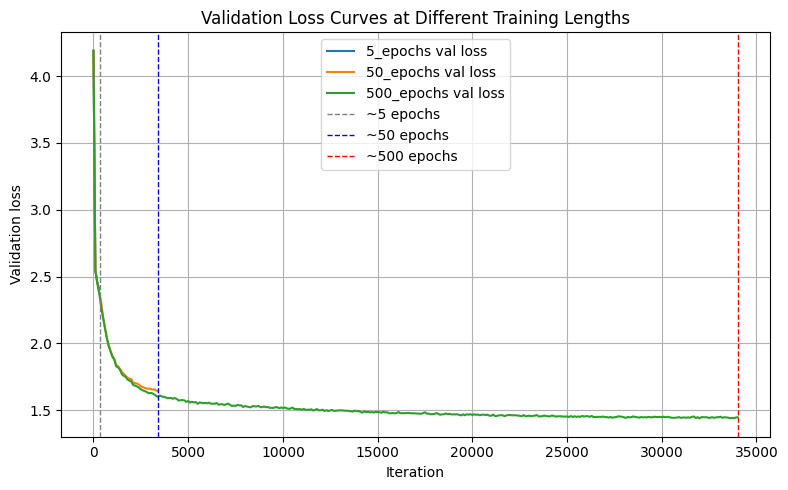

In [15]:
import matplotlib.pyplot as plt
import re

val_pattern = re.compile(r"step (\d+): train loss ([\d\.]+), val loss ([\d\.]+)")

plt.figure(figsize=(8, 5))

for label in ["5_epochs", "50_epochs", "500_epochs"]:
    log_path = f"logs/train_{label}.log"
    steps = []
    vals = []

    with open(log_path, "r") as f:
        for line in f:
            m = val_pattern.search(line)
            if m:
                steps.append(int(m.group(1)))
                vals.append(float(m.group(3)))

    if steps:
        plt.plot(steps, vals, label=f"{label} val loss")

# vertical lines for epoch checkpoints
plt.axvline(x=340, color='gray', linestyle='--', linewidth=1, label='~5 epochs')
plt.axvline(x=3400, color='blue', linestyle='--', linewidth=1, label='~50 epochs')
plt.axvline(x=34000, color='red', linestyle='--', linewidth=1, label='~500 epochs')

plt.xlabel("Iteration")
plt.ylabel("Validation loss")
plt.title("Validation Loss Curves at Different Training Lengths")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve_three_runs.png", dpi=200)
plt.show()

# Task 1: Language Modeling - Part B

In [16]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
block_size = 256
batch_size = 64
embed_size = 128
hidden_size = 256
n_layers = 2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load data
data_dir = 'data/shakespeare_char'
train_data = np.fromfile(os.path.join(data_dir, 'train.bin'), dtype=np.uint16)
val_data = np.fromfile(os.path.join(data_dir, 'val.bin'), dtype=np.uint16)

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([
        torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix
    ])
    y = torch.stack([
        torch.from_numpy((data[i+1:i+block_size+1]).astype(np.int64)) for i in ix
    ])
    return x.to(device), y.to(device)

# Load metadata
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

vocab_size = meta['vocab_size']
stoi, itos = meta['stoi'], meta['itos']

class ShakespeareLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            n_layers,
            batch_first=True,
            dropout=0.2 if n_layers > 1 else 0
        )
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embeds = self.embedding(x)
        out, hidden = self.lstm(embeds, hidden)
        logits = self.linear(out)
        return logits, hidden

model = ShakespeareLSTM(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

steps_per_epoch = 68
checkpoints = [5, 50, 500]
history = {'train': [], 'val': [], 'steps': []}

def estimate_loss(model, eval_iters=50):
    model.eval()
    results = {}
    with torch.no_grad():
        for split in ['train', 'val']:
            losses = []
            for _ in range(eval_iters):
                xb, yb = get_batch(split)
                logits, _ = model(xb)
                loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
                losses.append(loss.item())
            results[split] = sum(losses) / len(losses)
    model.train()
    return results

def generate(model, start_str="Love:", max_len=800):
    model.eval()
    chars = [stoi[c] for c in start_str]
    input_seq = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)
    hidden = None
    output = start_str

    with torch.no_grad():
        for _ in range(max_len):
            logits, hidden = model(input_seq, hidden)
            last_logit = logits[:, -1, :]
            probs = torch.softmax(last_logit, dim=-1)
            next_char_idx = torch.multinomial(probs, num_samples=1).item()
            output += itos[next_char_idx]
            input_seq = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return output

In [18]:
# Training
current_step = 0
for epoch_target in checkpoints:
    target_step = epoch_target * steps_per_epoch
    print(f"\n--- Training to Epoch {epoch_target} (Step {target_step}) ---")

    model.train()
    while current_step < target_step:
        xb, yb = get_batch('train')
        logits, _ = model(xb)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        current_step += 1

        if current_step % 100 == 0 or current_step == target_step:
            losses = estimate_loss(model, eval_iters=50)
            history['train'].append(losses['train'])
            history['val'].append(losses['val'])
            history['steps'].append(current_step)
    print(f"step {current_step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    print(f"\n--- Generating Sample for {epoch_target} Epochs (using start word 'Love:') ---")
    sample_text = generate(model, start_str="Love:", max_len=800)

    with open(f"lstm_sample_epoch_{epoch_target}.txt", "w") as f:
        f.write(sample_text)

    print(f"Character Count: {len(sample_text) - len('Love:')}")
    print(sample_text[:1200])


--- Training to Epoch 5 (Step 340) ---
step 340: train loss 1.1263, val loss 1.4840

--- Generating Sample for 5 Epochs (using start word 'Love:') ---
Character Count: 800
Love: if it catull jot oft his soldiers I give.

BUCKINGHAM:
God de ladling of a handless blood to find,
My tale unfoot to repent and bound to resign
And then in one our chich to Richard! O,
Let this as these condemnnd blessed true duty?
Then, whose straight?

EDWARD:
Not first to cure thee from your former suppliant
That is a place fled, towards apprachrees.

Second Servant:
Farewell;, bescer in place; and I mean severally
In time sight. Gentle, and a mean more catcher
To knows him are, from one martly stands prophet,
Still being castle us hav, and your husband.

GREGORY:
Wam all to him: his indeed will proffer I
Can sit my uncle, I wontend, to this way;
That thou unrivell's services, naked to melt.
If men so yet jost thou there's doubleness, and go.

BRAKENBURY:
He is from me, though they hav

--- Training to Epoc

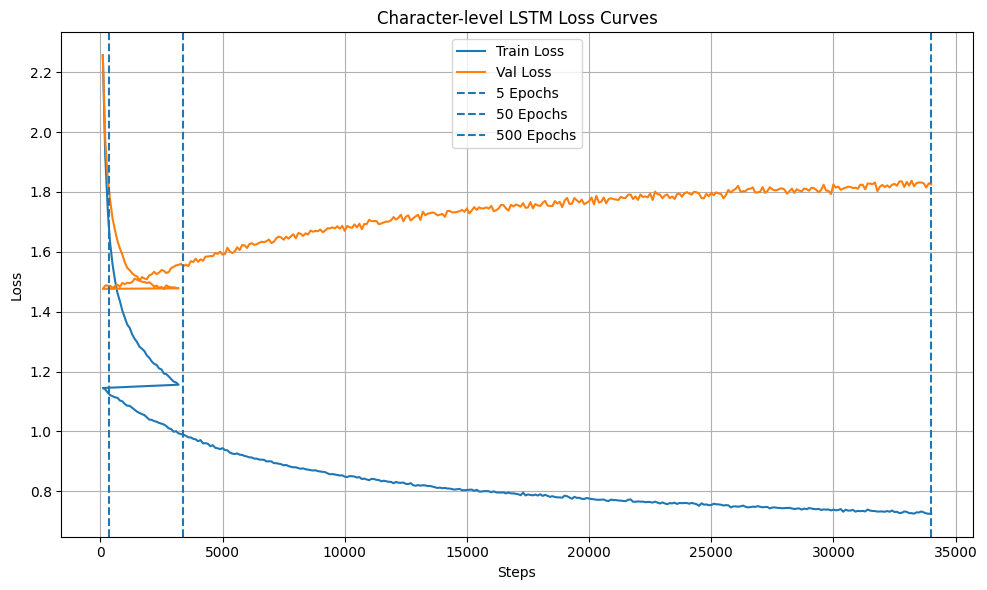

In [19]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(history['steps'], history['train'], label='Train Loss')
plt.plot(history['steps'], history['val'], label='Val Loss')

plt.axvline(x=5 * 68, linestyle='--', label='5 Epochs')
plt.axvline(x=50 * 68, linestyle='--', label='50 Epochs')
plt.axvline(x=500 * 68, linestyle='--', label='500 Epochs')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Character-level LSTM Loss Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Task 1: Language Modeling - Part C

**GPT vs LSTM Comparison at Different Checkpoints**

### ~5 Epochs

**Coherence**

* **GPT:** Very low coherence; mostly random characters and incomplete words.
* **LSTM:** Slightly better coherence; some recognizable words and short phrases appear.

**Formatting**

* **GPT:** Dialogue-like formatting appears occasionally but is inconsistent.
* **LSTM:** Some speaker-style formatting (e.g., `CHARACTER:`) begins to appear earlier.

**Repetition Loops**

* **GPT:** Few repetition loops because the model has not yet learned stable patterns.
* **LSTM:** Also minimal repetition, but sequences sometimes repeat small fragments.

**Character / Word Structure**

* **GPT:** Many broken or misspelled words and unstable capitalization.
* **LSTM:** Words are slightly more recognizable and character combinations are more stable.

---

### ~50 Epochs

**Coherence**

* **GPT:** Noticeably improved coherence; text resembles dialogue with partial sentence structure.
* **LSTM:** Coherence improves but remains weaker than GPT; sentences are often awkward or incomplete.

**Formatting**

* **GPT:** Dialogue formatting becomes clearer with recognizable speaker names.
* **LSTM:** Dialogue structure appears but is less consistent.

**Repetition Loops**

* **GPT:** Repetition remains limited.
* **LSTM:** Some repeated phrases or patterns start appearing.

**Character / Word Structure**

* **GPT:** Word spelling improves and sentences become more readable.
* **LSTM:** Words are readable but grammar and phrasing remain inconsistent.

---

### ~500 Epochs

**Coherence**

* **GPT:** High coherence; sentences and dialogue structure are more stable and understandable.
* **LSTM:** Coherence decreases relative to GPT; text often becomes fragmented or awkward.

**Formatting**

* **GPT:** Dialogue formatting is consistent and resembles Shakespeare-style conversations.
* **LSTM:** Formatting becomes less stable and sometimes breaks dialogue structure.

**Repetition Loops**

* **GPT:** Very few repetition loops.
* **LSTM:** More repetition and awkward phrasing appear.

**Character / Word Structure**

* **GPT:** Words and sentence structure are mostly correct.
* **LSTM:** Words remain readable but grammar and phrasing degrade due to overfitting.

---

### Significant Difference Between the Models

**Architecture Difference**

* **GPT:** Uses **self-attention**, allowing each token to directly consider all previous tokens within the context window. This helps capture long-range dependencies and maintain consistent dialogue structure.
* **LSTM:** Uses **recurrence**, passing information sequentially through hidden states. Information can degrade over long sequences, making it harder to maintain global context.

**Training Behavior**

* **GPT:** Maintains better generalization and stability during longer training.
* **LSTM:** Shows signs of **overfitting** at later stages (training loss decreases while validation loss increases), which leads to weaker coherence and more repetition in generated text.


# Task 2: Sequence Modeling Project

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU,
    Dense, Dropout, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBED_DIM = 64
BATCH_SIZE = 64
EPOCHS = 8
VAL_SPLIT = 0.2


IMDB Movie Review Dataset

Source: https://ai.stanford.edu/~amaas/data/sentiment/

Sequence models are appropriate for IMDB sentiment classification because each review is an ordered sequence of words, and meaning depends on word order and context. For example, “good” and “not good” have different meanings although they share similar words. RNN-based models can process token sequences step by step and preserve context across positions.

Original training samples: 25000
Original test samples: 25000
Train label distribution: [12500 12500]
Test label distribution: [12500 12500]
Train review length - min: 11 max: 2494 mean: 238.71364
Test review length - min: 7 max: 2315 mean: 230.8042


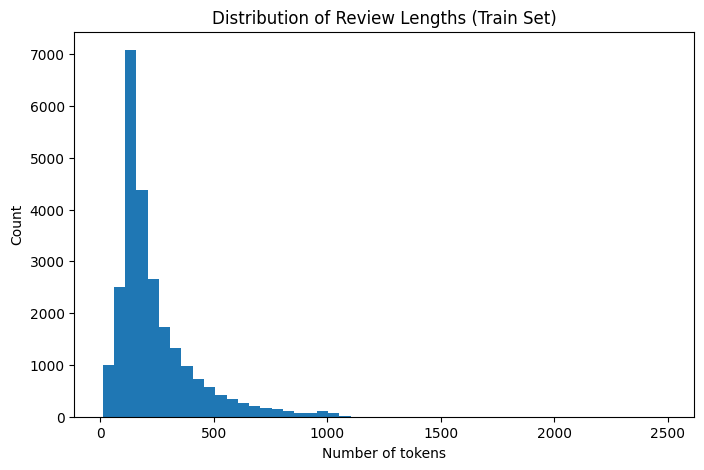

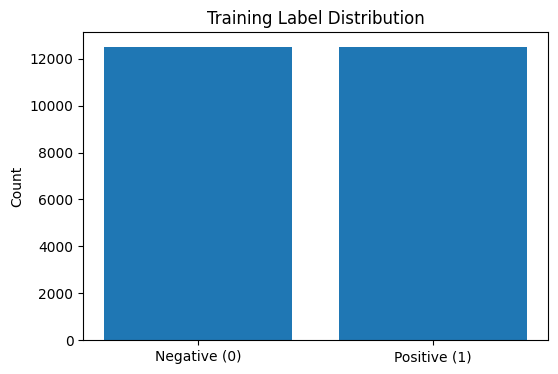

In [22]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Original training samples:", len(X_train))
print("Original test samples:", len(X_test))

train_lengths = [len(seq) for seq in X_train]
test_lengths = [len(seq) for seq in X_test]

print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))
print("Train review length - min:", np.min(train_lengths), "max:", np.max(train_lengths), "mean:", np.mean(train_lengths))
print("Test review length - min:", np.min(test_lengths), "max:", np.max(test_lengths), "mean:", np.mean(test_lengths))

plt.figure(figsize=(8, 5))
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Review Lengths (Train Set)")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(["Negative (0)", "Positive (1)"], np.bincount(y_train))
plt.title("Training Label Distribution")
plt.ylabel("Count")
plt.show()

Reviews were integer-encoded using the Keras IMDB dataset loader, restricted to the top 10,000 most frequent words. Each review was padded or truncated to length 200 so that all samples had the same input size.

In [23]:
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (25000, 200)
X_test_pad shape: (25000, 200)


In [24]:
word_index = imdb.get_word_index()
index_to_word = {idx + 3: word for word, idx in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(index_to_word.get(i, "?") for i in encoded_review)

print(decode_review(X_train[0][:100]))
print("Label:", y_train[0])

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was
Label: 1


In [27]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).reshape(-1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {model_name} Test Results ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def train_model(model, model_name):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad, y_train,
        validation_split=VAL_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    model.summary()
    plot_history(history, model_name)
    metrics = evaluate_model(model, X_test_pad, y_test, model_name)

    return model, history, metrics

Basic RNN:
- Uses recurrent hidden states across time steps.
- Time-step activation: tanh
- Output activation: sigmoid

LSTM:
- Uses gates to better preserve long-term information.
- Usually handles longer dependencies better than basic RNN.

GRU:
- Similar idea to LSTM but simpler.
- Often trains faster while keeping strong performance.

Feed-forward network:
- Can work after converting the sequence into a fixed-size representation.
- But it does not model word order as explicitly as RNN/LSTM/GRU.


Basic RNN: Embedding layer (10000, 64) → SimpleRNN(64, tanh) → Dense(1, sigmoid)

LSTM: Embedding layer → LSTM(64, tanh) → Dense(1, sigmoid)

GRU: Embedding layer → GRU(64, tanh) → Dense(1, sigmoid)

Feed-forward baseline: Embedding layer → GlobalAveragePooling1D → Dense(64, relu) → Dropout(0.3) → Dense(1, sigmoid)


Can you use a traditional feed-forward network? Why or why not?

Yes, a traditional feed-forward network can be used if the sequence is converted into a fixed-size representation, such as averaged embeddings or engineered features. However, it does not explicitly model temporal or sequential dependencies as RNN, LSTM, and GRU do. Therefore, while it can work well on some tasks like sentiment classification, it may lose important word-order information.

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.5020 - loss: 0.6952 - val_accuracy: 0.4898 - val_loss: 0.7353
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5511 - loss: 0.6866 - val_accuracy: 0.4982 - val_loss: 0.7008
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6099 - loss: 0.6360 - val_accuracy: 0.4924 - val_loss: 0.7934
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6196 - loss: 0.6131 - val_accuracy: 0.5094 - val_loss: 0.7924


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,944,965 (7.42 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,296,644 (4.95 MB)

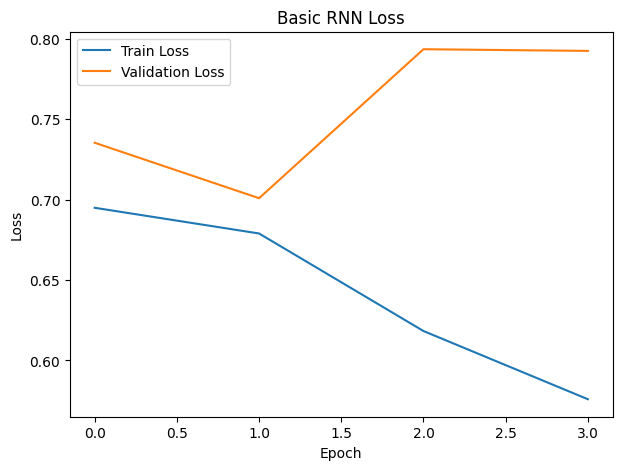

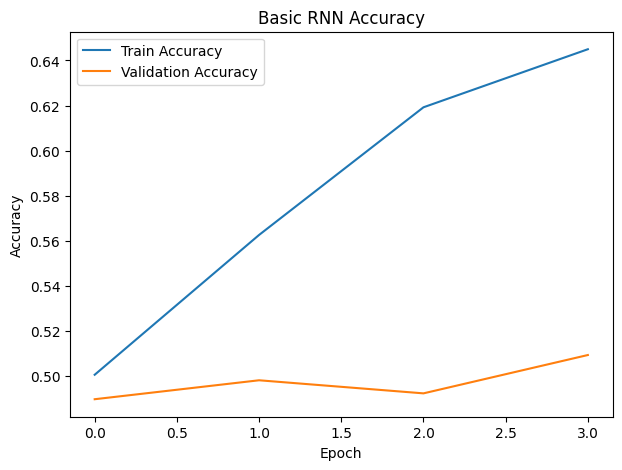


=== Basic RNN Test Results ===
Accuracy : 0.5038
Precision: 0.5038
Recall   : 0.5047
F1 Score : 0.5043
Confusion Matrix:
[[6287 6213]
 [6191 6309]]


In [31]:
# Build Basic RNN model
def build_simple_rnn():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

simple_rnn_model, simple_rnn_history, simple_rnn_metrics = train_model(
    build_simple_rnn(), "Basic RNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5130 - loss: 0.6930 - val_accuracy: 0.5482 - val_loss: 0.6833
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5828 - loss: 0.6679 - val_accuracy: 0.5392 - val_loss: 0.6833
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6032 - loss: 0.6419 - val_accuracy: 0.6336 - val_loss: 0.6431
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7958 - loss: 0.4704 - val_accuracy: 0.8512 - val_loss: 0.3667
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8946 - loss: 0.2736 - val_accuracy: 0.8654 - val_loss: 0.3404
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9304 - loss: 0.2016 - val_accuracy: 0.8574 - val_loss: 0.3874
Epoch 7/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9498 - loss: 0.1546 - val_accuracy: 0.8614 - val_loss: 0.4310


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,269 (7.70 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,346,180 (5.14 MB)

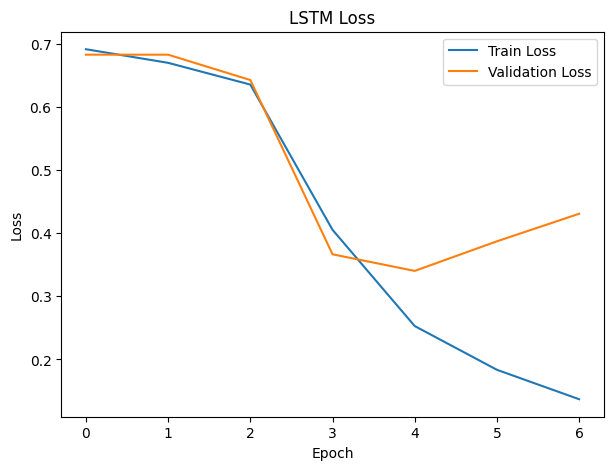

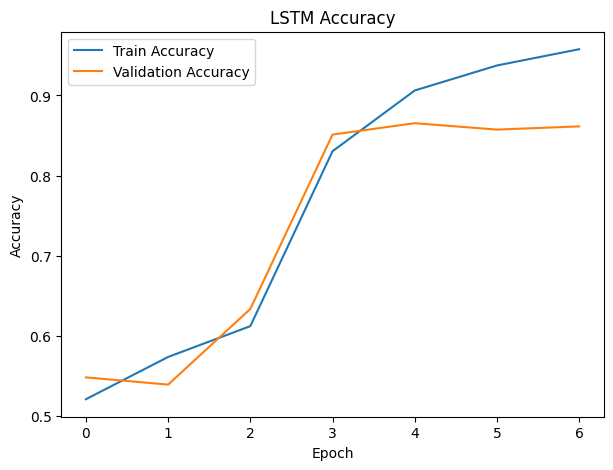


=== LSTM Test Results ===
Accuracy : 0.8485
Precision: 0.8628
Recall   : 0.8289
F1 Score : 0.8455
Confusion Matrix:
[[10852  1648]
 [ 2139 10361]]


In [32]:
# Build LSTM model
def build_lstm():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

lstm_model, lstm_history, lstm_metrics = train_model(
    build_lstm(), "LSTM")

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5103 - loss: 0.6932 - val_accuracy: 0.5556 - val_loss: 0.6834
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5832 - loss: 0.6578 - val_accuracy: 0.6618 - val_loss: 0.6472
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7159 - loss: 0.5635 - val_accuracy: 0.6860 - val_loss: 0.5904
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7383 - loss: 0.5295 - val_accuracy: 0.6848 - val_loss: 0.5924
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7699 - loss: 0.4976 - val_accuracy: 0.7672 - val_loss: 0.5159
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7494 - loss: 0.5330 - val_accuracy: 0.7604 - val_loss: 0.5213
Epoch 7/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8368 - loss: 0.3790 - val_accuracy: 0.7990 - val_loss: 0.4905
Epoch 8/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8500 - loss: 0.3635 - val_accuracy: 0.7952 - val

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,995,077 (7.61 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,330,052 (5.07 MB)

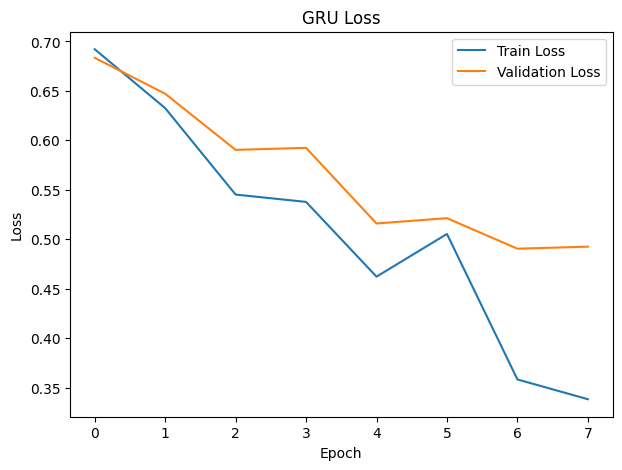

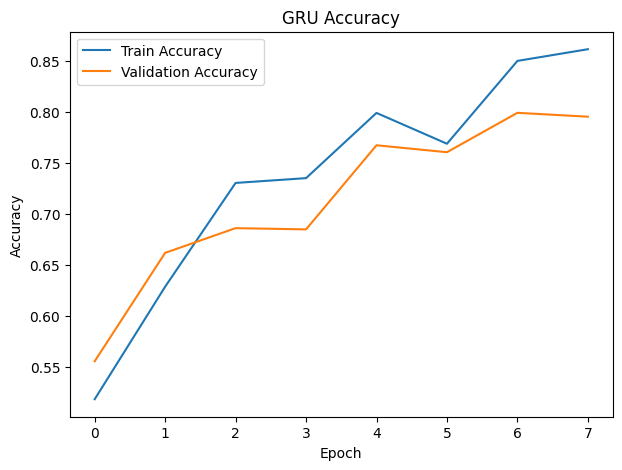


=== GRU Test Results ===
Accuracy : 0.7796
Precision: 0.8108
Recall   : 0.7294
F1 Score : 0.7680
Confusion Matrix:
[[10373  2127]
 [ 3382  9118]]


In [33]:
# Build GRU model
def build_gru():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

gru_model, gru_history, gru_metrics = train_model(
    build_gru(), "GRU")

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6238 - loss: 0.6375 - val_accuracy: 0.8532 - val_loss: 0.3645
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8572 - loss: 0.3389 - val_accuracy: 0.8638 - val_loss: 0.3254
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8942 - loss: 0.2654 - val_accuracy: 0.8680 - val_loss: 0.3260
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.2223 - val_accuracy: 0.8692 - val_loss: 0.3365


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

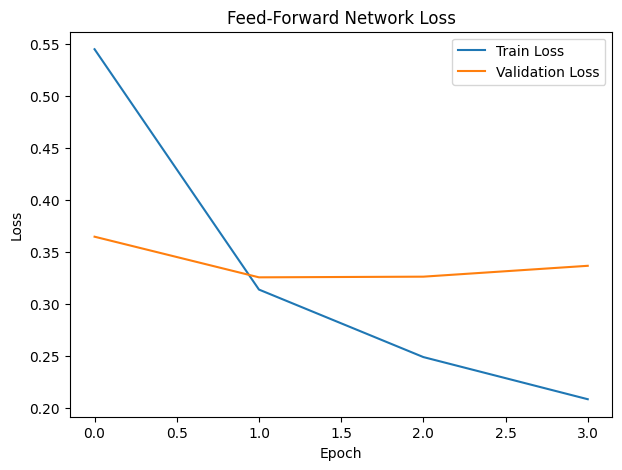

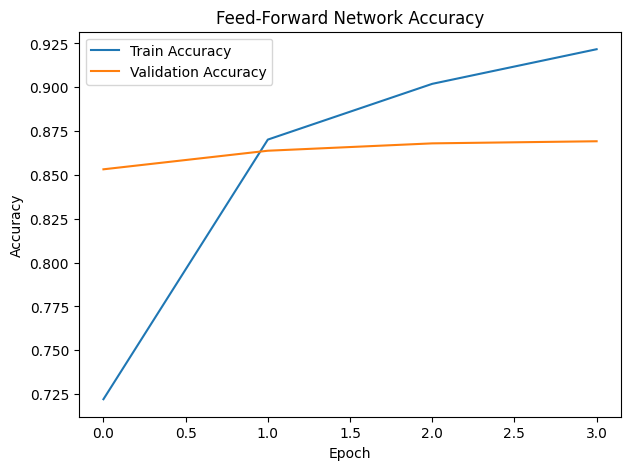


=== Feed-Forward Network Test Results ===
Accuracy : 0.8531
Precision: 0.8352
Recall   : 0.8799
F1 Score : 0.8570
Confusion Matrix:
[[10329  2171]
 [ 1501 10999]]


In [34]:
# Build feed-forward baseline
def build_feedforward():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

ffn_model, ffn_history, ffn_metrics = train_model(
    build_feedforward(), "Feed-Forward Network")

In [35]:
all_results = [
    simple_rnn_metrics,
    lstm_metrics,
    gru_metrics,
    ffn_metrics
]

print("\nFinal Comparison")
for r in all_results:
    print(
        f"{r['Model']:<22}"
        f" Accuracy={r['Accuracy']:.4f}"
        f" Precision={r['Precision']:.4f}"
        f" Recall={r['Recall']:.4f}"
        f" F1={r['F1']:.4f}"
    )


Final Comparison
Basic RNN              Accuracy=0.5038 Precision=0.5038 Recall=0.5047 F1=0.5043
LSTM                   Accuracy=0.8485 Precision=0.8628 Recall=0.8289 F1=0.8455
GRU                    Accuracy=0.7796 Precision=0.8108 Recall=0.7294 F1=0.7680
Feed-Forward Network   Accuracy=0.8531 Precision=0.8352 Recall=0.8799 F1=0.8570


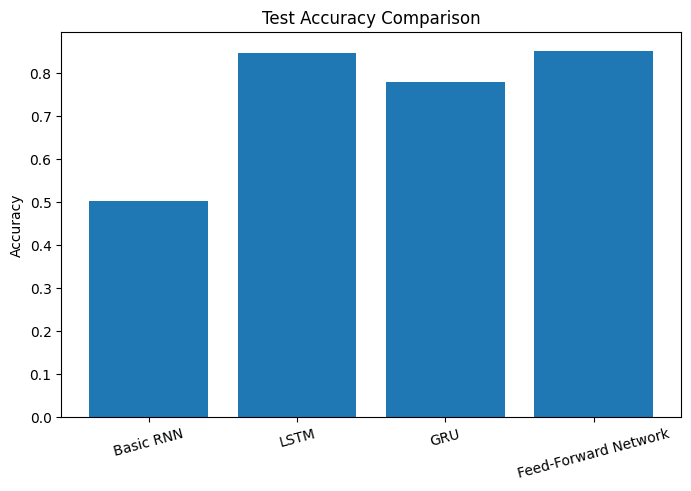

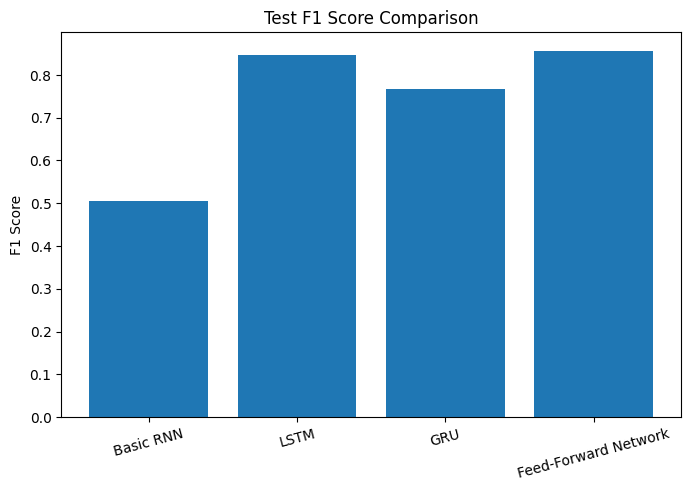

In [36]:
model_names = [r["Model"] for r in all_results]
acc_scores = [r["Accuracy"] for r in all_results]
f1_scores = [r["F1"] for r in all_results]

plt.figure(figsize=(8, 5))
plt.bar(model_names, acc_scores)
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_names, f1_scores)
plt.title("Test F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.show()

Basic RNN performed very poorly, around random guessing.

LSTM performed much better than Basic RNN.

GRU improved over Basic RNN but underperformed LSTM.

Feed-forward network performed slightly better than LSTM in this setup.

Why:

Basic RNN often struggles with long-range dependencies and vanishing gradients.

LSTM uses gating mechanisms that preserve useful information over longer sequences.

GRU also uses gates, but is simpler than LSTM and may sometimes trade a bit of performance for efficiency.

The feed-forward model did well because average-pooled embeddings can already capture strong sentiment cues in this dataset, even without modeling sequence order explicitly.

# Task 3 - Part 1:  Implementing Word Embeddings

In [50]:
!pip install gensim

import gensim.downloader as api
import numpy as np

print("Loading GloVe embeddings...")
model = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(model))
print("Embedding dimension:", model.vector_size)

Loading GloVe embeddings...
Vocabulary size: 400000
Embedding dimension: 100


In [51]:
# Function to Get Word Embeddings
def get_embedding(word):

    if word in model:
        vector = model[word]
        print(f"\nEmbedding for '{word}':")
        print(vector[:10], "...")   # print first 10 values
        return vector

    else:
        print(f"\n'{word}' is out-of-vocabulary (OOV).")
        return None

# Handle Out-of-Vocabulary Words
def get_embedding_with_oov(word):
    if word in model:
        print(f"Embedding for '{word}':")
        print(model[word][:10], "...")
        return model[word]

    print(f"'{word}' is out-of-vocabulary (OOV).")

    if word.lower() in model:
        print(f"Using lowercase approximation: '{word.lower()}'")
        return model[word.lower()]

    for suffix in ["ing", "ed", "s"]:
        if word.endswith(suffix):
            base = word[:-len(suffix)]
            if base in model:
                print(f"Using base-word approximation: '{base}'")
                return model[base]

    print("No direct approximation found.")
    print("Possible strategies: lowercase conversion, stemming/lemmatization, or using FastText subword embeddings.")
    return None

# Dynamic User Input
word1 = 'king'
word2 = 'queen'
print(f'word1 = {word1}, word2 = {word2}')
vec1 = get_embedding(word1)
vec2 = get_embedding(word2)



word1 = "king"
word2 = "HELLO"
print(f'\nword1 = {word1}, word2 = {word2}')
vec1 = get_embedding_with_oov(word1)
vec2 = get_embedding_with_oov(word2)

word1 = "king"
word2 = "helloooo"
print(f'\nword1 = {word1}, word2 = {word2}')
vec1 = get_embedding_with_oov(word1)
vec2 = get_embedding_with_oov(word2)

word1 = king, word2 = queen

Embedding for 'king':
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ] ...

Embedding for 'queen':
[-0.50045 -0.70826  0.55388  0.673    0.22486  0.60281 -0.26194  0.73872
 -0.65383 -0.21606] ...

word1 = king, word2 = HELLO
Embedding for 'king':
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ] ...
'HELLO' is out-of-vocabulary (OOV).
Using lowercase approximation: 'hello'

word1 = king, word2 = helloooo
Embedding for 'king':
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ] ...
'helloooo' is out-of-vocabulary (OOV).
No direct approximation found.
Possible strategies: lowercase conversion, stemming/lemmatization, or using FastText subword embeddings.


### Why GloVe was chosen over other embeddings?

GloVe was selected because it is a pre-trained static word embedding model that is lightweight, efficient, and easy to use with Gensim. Compared with Word2Vec, GloVe captures global word co-occurrence statistics from the corpus, which often improves semantic relationships. Compared with FastText, GloVe does not model subword units, so it is less robust for rare or misspelled words, but it is simpler and sufficient for standard vocabulary demonstrations. Compared with BERT, GloVe is much less computationally expensive and produces one fixed vector per word, which is appropriate for this assignment because the task asks for direct word embeddings rather than contextual sentence-dependent embeddings.

# Task 3 - Part 2: Cosine Similarity Computation

In [56]:
from numpy.linalg import norm

# Cosine similarity function
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# Updated function: get_embedding_with_oov
def get_embedding_with_oov(word):
    if word in model:
        return model[word], word
    if word.lower() in model:
        print(f"'{word}' is OOV. Using lowercase approximation: '{word.lower()}'")
        return model[word.lower()], word.lower()
    for suffix in ["ing", "ed", "s"]:
        if word.endswith(suffix):
            base = word[:-len(suffix)]
            if base in model:
                print(f"'{word}' is OOV. Using base-word approximation: '{base}'")
                return model[base], base
    print(f"'{word}' is OOV. No direct approximation found.")
    return None, None

# Compare two words
def compare_words(word1, word2):

    vec1, used1 = get_embedding_with_oov(word1)
    vec2, used2 = get_embedding_with_oov(word2)

    if vec1 is None or vec2 is None:
        print("Cannot compute similarity.")
        return

    sim = cosine_similarity(vec1, vec2)

    print(f"\nWord1: {word1} (used: {used1})")
    print(f"Word2: {word2} (used: {used2})")
    print(f"Cosine similarity: {sim:.4f}")

compare_words("king", "queen")
compare_words("car", "automobile")
compare_words("king", "banana")


Word1: king (used: king)
Word2: queen (used: queen)
Cosine similarity: 0.7508

Word1: car (used: car)
Word2: automobile (used: automobile)
Cosine similarity: 0.6832

Word1: king (used: king)
Word2: banana (used: banana)
Cosine similarity: 0.1609


In [57]:
# Batch similarity for multiple pairs
def batch_similarity(pairs):

    for w1, w2 in pairs:
        vec1, _ = get_embedding_with_oov(w1)
        vec2, _ = get_embedding_with_oov(w2)

        if vec1 is None or vec2 is None:
            print(f"{w1} - {w2}: similarity unavailable")
        else:
            sim = cosine_similarity(vec1, vec2)
            print(f"{w1:10s} {w2:10s} similarity = {sim:.4f}")

pairs = [
    ("king", "queen"),
    ("dog", "cat"),
    ("car", "banana"),
    ("man", "woman")
]

batch_similarity(pairs)

king       queen      similarity = 0.7508
dog        cat        similarity = 0.8798
car        banana     similarity = 0.1486
man        woman      similarity = 0.8323


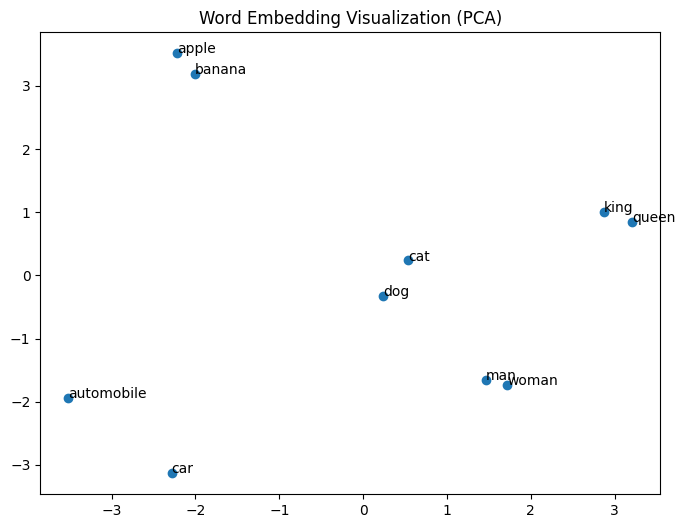

In [58]:
# Visualization using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def visualize_words(words):

    vectors = []
    labels = []

    for w in words:
        vec, used = get_embedding_with_oov(w)
        if vec is not None:
            vectors.append(vec)
            labels.append(used)

    vectors = np.array(vectors)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1])

    for i, word in enumerate(labels):
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title("Word Embedding Visualization (PCA)")
    plt.show()

visualize_words([
    "king","queen","man","woman",
    "dog","cat","car","automobile",
    "apple","banana"
])

### Why cosine similarity is useful?

Cosine similarity measures the angle between two embedding vectors rather than their magnitude. In word embedding space, semantic similarity is usually reflected by vector direction. Words with similar meanings tend to have vectors pointing in similar directions, producing cosine similarity values close to 1. Words that are unrelated have values closer to 0.

### About PCA plot:
In the PCA visualization, semantically related words such as “king” and “queen” or “dog” and “cat” appear closer together, while unrelated words such as “car” and “banana” are farther apart.

# Task 3 - Part 3: Designing a Novel Dissimilarity Metric

In [59]:
from numpy.linalg import norm

# Add new dissimilarity functions
def cosine_dissimilarity(vec1, vec2):
    return 1 - cosine_similarity(vec1, vec2)

def euclidean_distance(vec1, vec2):
    return norm(vec1 - vec2)

def custom_dissimilarity(vec1, vec2, alpha=0.7):
    cos_part = cosine_dissimilarity(vec1, vec2)
    euc_part = euclidean_distance(vec1, vec2)
    euc_part = euc_part / (1 + euc_part)   # normalize
    return alpha * cos_part + (1 - alpha) * euc_part


# Add one unified score function with toggle
def compute_score(word1, word2, metric="custom", alpha=0.7):
    vec1, used1 = get_embedding_with_oov(word1)
    vec2, used2 = get_embedding_with_oov(word2)

    if vec1 is None or vec2 is None:
        print("Cannot compute score because one or both words are unavailable.")
        return None

    if metric == "cosine":
        score = cosine_similarity(vec1, vec2)
        print(f"{word1} vs {word2} | cosine similarity = {score:.4f}")
    elif metric == "cosine_dissim":
        score = cosine_dissimilarity(vec1, vec2)
        print(f"{word1} vs {word2} | cosine dissimilarity = {score:.4f}")
    elif metric == "euclidean":
        score = euclidean_distance(vec1, vec2)
        print(f"{word1} vs {word2} | euclidean distance = {score:.4f}")
    elif metric == "custom":
        score = custom_dissimilarity(vec1, vec2, alpha=alpha)
        print(f"{word1} vs {word2} | custom dissimilarity = {score:.4f}")
    else:
        raise ValueError("metric must be one of: cosine, cosine_dissim, euclidean, custom")

    return score


compute_score("cat", "dog", metric="cosine")
compute_score("cat", "dog", metric="euclidean")
compute_score("cat", "table", metric="custom")

cat vs dog | cosine similarity = 0.8798
cat vs dog | euclidean distance = 2.6811
cat vs table | custom dissimilarity = 0.7410


np.float32(0.7410482)

In [60]:
# Rank words against one query word
def rank_words(query_word, candidate_words, metric="custom", alpha=0.7):
    query_vec, used_query = get_embedding_with_oov(query_word)
    if query_vec is None:
        print("Query word unavailable.")
        return []

    results = []

    for w in candidate_words:
        vec, used_w = get_embedding_with_oov(w)
        if vec is None:
            continue

        if metric == "cosine":
            score = cosine_similarity(query_vec, vec)
        elif metric == "cosine_dissim":
            score = cosine_dissimilarity(query_vec, vec)
        elif metric == "euclidean":
            score = euclidean_distance(query_vec, vec)
        elif metric == "custom":
            score = custom_dissimilarity(query_vec, vec, alpha=alpha)
        else:
            raise ValueError("metric must be one of: cosine, cosine_dissim, euclidean, custom")

        results.append((used_w, score))

    if metric == "cosine":
        results.sort(key=lambda x: x[1], reverse=True)
    else:
        results.sort(key=lambda x: x[1])

    return results


candidates = ["dog", "lion", "table", "tiger", "car", "kitten", "banana"]
print(rank_words("cat", candidates, metric="custom"))
print(rank_words("cat", candidates, metric="cosine"))

[('dog', np.float32(0.302638)), ('lion', np.float32(0.5308424)), ('kitten', np.float32(0.55436105)), ('tiger', np.float32(0.5724554)), ('table', np.float32(0.7410482)), ('car', np.float32(0.74359655)), ('banana', np.float32(0.76738083))]
[('dog', np.float32(0.8798076)), ('lion', np.float32(0.5955515)), ('kitten', np.float32(0.5580502)), ('tiger', np.float32(0.5415419)), ('car', np.float32(0.31097823)), ('table', np.float32(0.31008098)), ('banana', np.float32(0.2737714))]


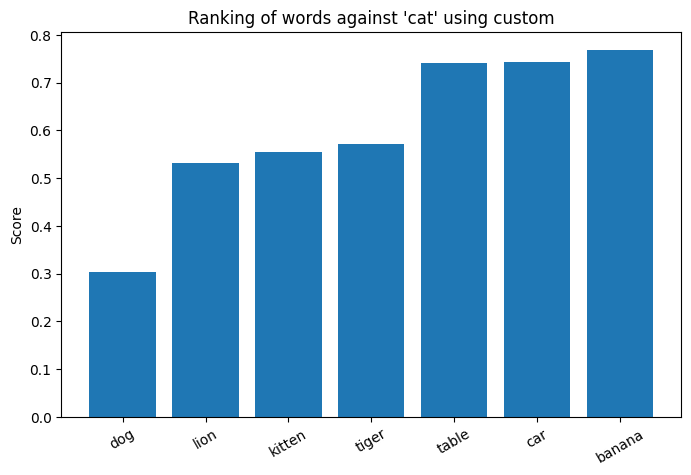

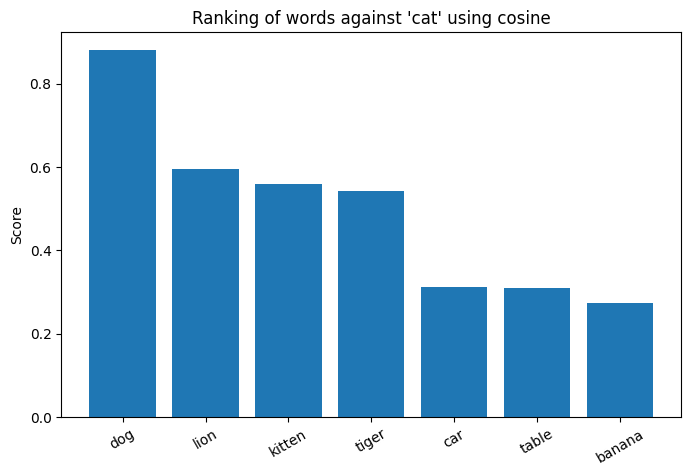

In [61]:
def plot_ranking(query_word, candidate_words, metric="custom", alpha=0.7):
    ranked = rank_words(query_word, candidate_words, metric=metric, alpha=alpha)

    words = [w for w, s in ranked]
    scores = [s for w, s in ranked]

    plt.figure(figsize=(8, 5))
    plt.bar(words, scores)
    plt.title(f"Ranking of words against '{query_word}' using {metric}")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    plt.show()

plot_ranking("cat", ["dog", "lion", "table", "tiger", "car", "kitten", "banana"], metric="custom")
plot_ranking("cat", ["dog", "lion", "table", "tiger", "car", "kitten", "banana"], metric="cosine")

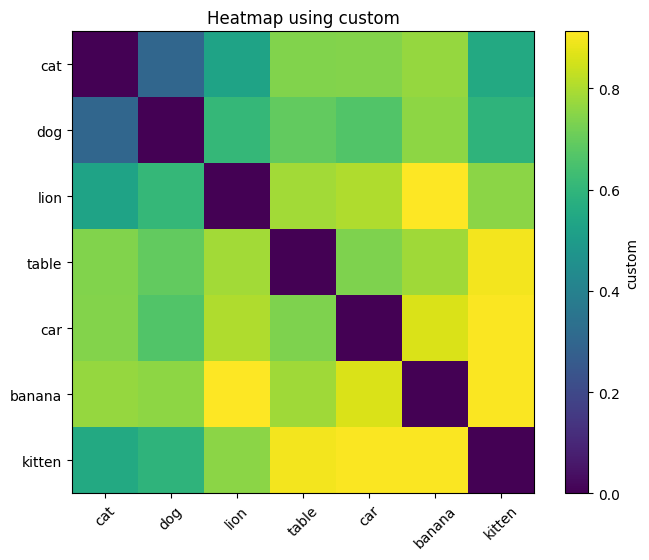

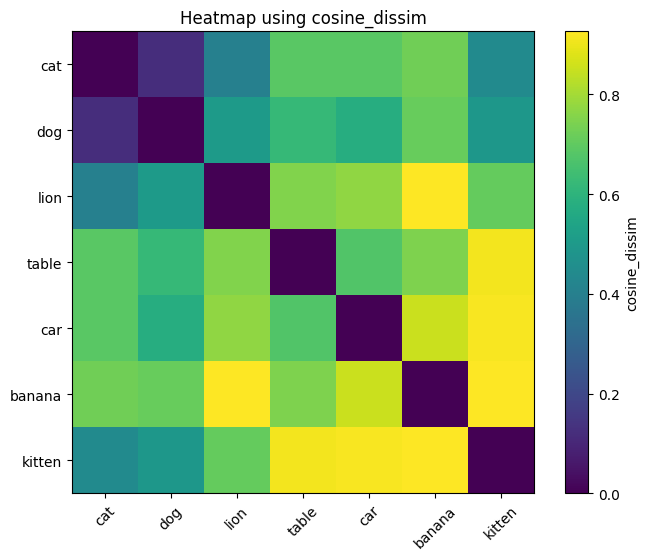

In [62]:
def build_matrix(words, metric="custom", alpha=0.7):
    valid_words = []
    vectors = []

    for w in words:
        vec, used = get_embedding_with_oov(w)
        if vec is not None:
            valid_words.append(used)
            vectors.append(vec)

    n = len(vectors)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if metric == "cosine":
                matrix[i, j] = cosine_similarity(vectors[i], vectors[j])
            elif metric == "cosine_dissim":
                matrix[i, j] = cosine_dissimilarity(vectors[i], vectors[j])
            elif metric == "euclidean":
                matrix[i, j] = euclidean_distance(vectors[i], vectors[j])
            elif metric == "custom":
                matrix[i, j] = custom_dissimilarity(vectors[i], vectors[j], alpha=alpha)
            else:
                raise ValueError("metric must be one of: cosine, cosine_dissim, euclidean, custom")

    return valid_words, matrix


def plot_heatmap(words, metric="custom", alpha=0.7):
    labels, matrix = build_matrix(words, metric=metric, alpha=alpha)

    plt.figure(figsize=(8, 6))
    plt.imshow(matrix, cmap="viridis")
    plt.colorbar(label=metric)
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.title(f"Heatmap using {metric}")
    plt.show()


words = ["cat", "dog", "lion", "table", "car", "banana", "kitten"]
plot_heatmap(words, metric="custom")
plot_heatmap(words, metric="cosine_dissim")

### Designing a Novel Dissimilarity Metric

In this part, I define a custom dissimilarity score that combines cosine dissimilarity and Euclidean distance:


$$D_{\text{custom}}(x,y) = \alpha (1 - \cos(x,y)) + (1-\alpha)\frac{\|x-y\|_2}{1+\|x-y\|_2}$$

This metric goes beyond cosine similarity alone because cosine only measures angular difference, while Euclidean distance measures absolute separation in embedding space. By combining both, the custom metric captures novelty and diversity more effectively.

cat vs dog | custom dissimilarity = 0.3026
cat vs table | custom dissimilarity = 0.7410


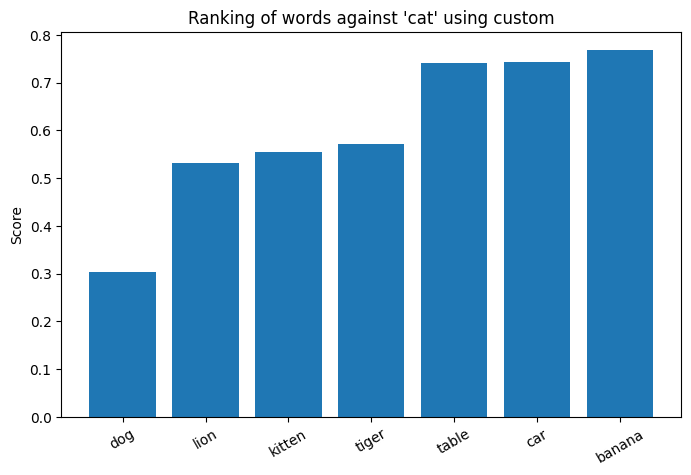

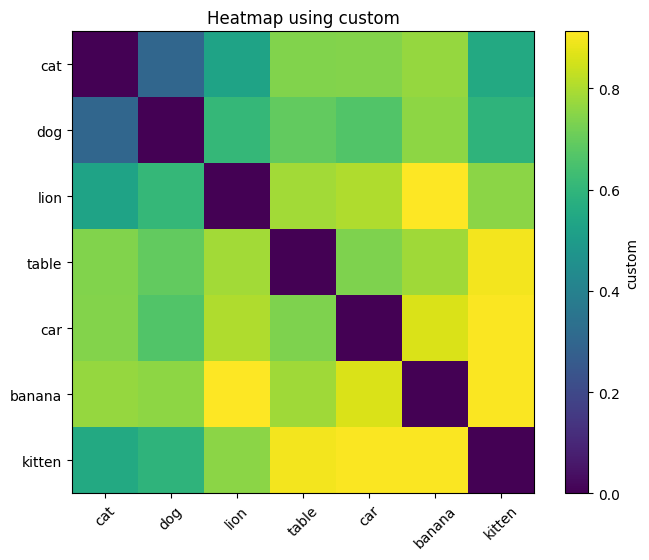

In [63]:
compute_score("cat", "dog", metric="custom")
compute_score("cat", "table", metric="custom")

plot_ranking("cat", ["dog", "lion", "table", "tiger", "car", "kitten", "banana"], metric="custom")

plot_heatmap(["cat", "dog", "lion", "table", "car", "banana", "kitten"], metric="custom")

### One sentence interpretate ranking
Under the custom metric, words such as “dog,” “lion,” and “kitten” rank closer to “cat,” while unrelated words such as “table” and “banana” receive larger dissimilarity scores.